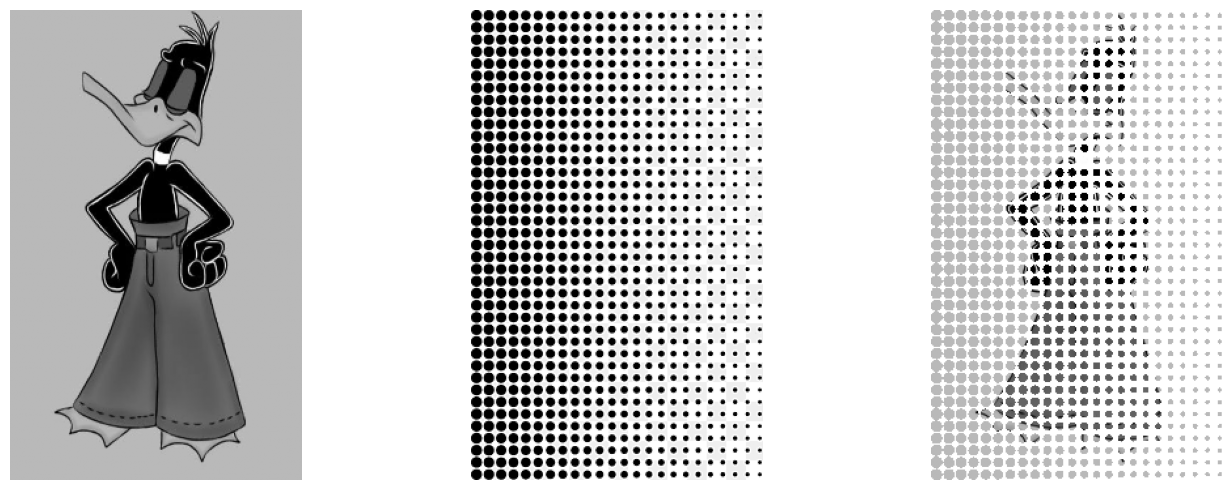

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path_puntos = r'D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\LABORATORIOS\LAB 2\img laboratorio\puntos.png'
path_dibujo = r'D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\LABORATORIOS\LAB 2\img laboratorio\pato.jpg'

puntos = cv2.imread(path_puntos, cv2.IMREAD_GRAYSCALE)
dibujo = cv2.imread(path_dibujo, cv2.IMREAD_GRAYSCALE)

if puntos.shape != dibujo.shape:
    dibujo = cv2.resize(dibujo, (puntos.shape[1], puntos.shape[0]))

combinada = np.where(puntos > 200, 255, dibujo)  

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dibujo, cmap="gray")
plt.axis('off')
plt.subplot(132)
plt.imshow(puntos, cmap="gray") 
plt.axis('off')
plt.subplot(133)
plt.imshow(combinada, cmap="gray") 
plt.axis('off')
plt.tight_layout()
plt.show()


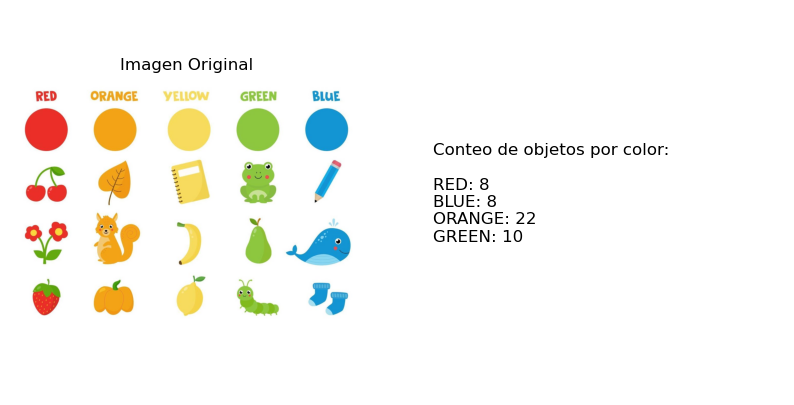

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_objetos_por_color(imagen):
    img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    _, binarizada = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    etiquetas = measure.label(binarizada, connectivity=2)
    regiones = measure.regionprops(etiquetas)
    
    conteo = {}

    for region in regiones:
        minr, minc, maxr, maxc = region.bbox
        objeto = hsv[minr:maxr, minc:maxc]
        if objeto.size == 0:
            continue
        hue = objeto[:, :, 0].flatten()
        dominant = np.argmax(np.histogram(hue, bins=180, range=(0, 180))[0])

        if (0 <= dominant < 10) or (dominant >= 160): color = 'RED'
        elif 10 <= dominant < 25: color = 'ORANGE'
        elif 25 <= dominant < 35: color = 'YELLOW'
        elif 35 <= dominant < 85: color = 'GREEN'
        elif 85 <= dominant < 130: color = 'BLUE'
        else: color = 'OTHER'

        if color in conteo:
            conteo[color] += 1
        else:
            conteo[color] = 1

    return conteo, img_rgb

imagen = cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\LABORATORIOS\LAB 2\img laboratorio\colores.jpg")

conteo, img = contar_objetos_por_color(imagen)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')
plt.title("Imagen Original")

plt.subplot(1, 2, 2)
plt.axis('off')
text = "Conteo de objetos por color:\n\n"
for color, cantidad in conteo.items():
    text += f"{color}: {cantidad}\n"
plt.text(0, 0.5, text, fontsize=12, va='center')

plt.show()


eje3

primero, tendría que cargar la imagen en escala de grises, ya que el operador de canny trabaja mejor con una sola capa de intensidad. luego, usaría un filtro gaussiano para suavizar la imagen y reducir el ruido, lo cual es importante para evitar detectar bordes falsos. después, aplicaría el operador de canny, el cual detecta los bordes encontrando cambios bruscos de intensidad en la imagen. para ello, se le dan dos umbrales: uno bajo y otro alto, que ayudan a definir qué bordes son importantes. finalmente, mostraría la imagen original junto con la imagen con los bordes detectados, lo cual me permitiría ver claramente los contornos del rostro.